In [1]:
%cd continue

[Errno 2] No such file or directory: 'continue'
/content


Ma'lumotlarni github da, Data setni chaqirib olamiz.

In [2]:
! git clone https://github.com/valixonovai/ML.git

Cloning into 'ML'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 9 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 617.11 KiB | 5.27 MiB/s, done.


# Bank mijozlarining qarzni qaytarish prognozi

**Barcha kutubxonalar**

In [3]:
import numpy as np
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import confusion_matrix , accuracy_score
from sklearn import svm,tree
from sklearn.neighbors import KNeighborsClassifier


In [4]:
df = pd.read_csv("/content/ML/train.csv")
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15702656.0,Nwora,567.0,France,Male,33.0,9.0,0.0,2.0,1.0,0.0,156792.89,0.0
1,1,15647965.0,Yevdokimova,628.0,France,Female,38.0,3.0,0.0,1.0,1.0,1.0,51987.99,1.0
2,2,15798834.0,Ch'iu,635.0,France,Female,29.0,3.0,0.0,2.0,1.0,1.0,113079.19,0.0
3,3,15672056.0,Hsia,681.0,France,Male,28.0,6.0,0.0,2.0,1.0,0.0,14081.64,0.0
4,4,15759537.0,Okwudilichukwu,587.0,France,Female,27.0,5.0,0.0,2.0,1.0,0.0,158958.90,0.0


In [5]:
df.tail()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
14995,14995,15733888.0,H?,581.0,France,Male,35.0,1.0,0.00,2.0,1.0,0.0,161653.50,0.0
14996,14996,15740164.0,Ch'in,806.0,Germany,Male,42.0,1.0,129120.64,2.0,1.0,1.0,161642.08,0.0
14997,14997,15629002.0,Shubin,620.0,France,Female,29.0,7.0,0.00,2.0,1.0,1.0,161579.85,0.0
14998,14998,15684548.0,Ch'in,622.0,Germany,Male,51.0,6.0,106070.89,3.0,1.0,0.0,136869.31,1.0
14999,14999,15572361.0,Trevisano,543.0,France,Male,36.0,8.0,0.00,1.0,1.0,1.0,163568.33,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


In [7]:
df.describe(include = "all")

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,15000.000000,1.500000e+04,15000,15000.000000,15000,15000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
unique,NaN,NaN,758,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Ch'iu,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,284,NaN,9040,8478,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,7499.500000,1.579454e+07,NaN,657.856800,NaN,NaN,37.710133,5.018667,42338.107539,1.590533,0.779133,0.496000,116944.059867,0.198467
std,4330.271354,1.268495e+07,NaN,72.678739,NaN,NaN,8.144880,2.787407,59703.047751,0.525822,0.414845,0.500001,46047.485455,0.398859
min,0.000000,1.567151e+05,NaN,431.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,3749.750000,1.563435e+07,NaN,602.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,82644.332500,0.000000
50%,7499.500000,1.568947e+07,NaN,661.000000,NaN,NaN,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,122449.420000,0.000000
75%,11249.250000,1.575682e+07,NaN,707.000000,NaN,NaN,42.000000,7.000000,109636.342500,2.000000,1.000000,1.000000,155703.022500,0.000000


In [8]:
df.isnull().sum()

,0
id,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [9]:
df[df.duplicated(keep=False)]

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


In [10]:
df.corr(numeric_only=True)

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
id,1.000000,-0.013143,0.002450,0.008301,0.010274,0.002993,-0.003234,0.007082,0.012198,0.006161,-0.015533
CustomerId,-0.013143,1.000000,0.014209,-0.001726,-0.005906,-0.005943,0.006489,-0.015185,0.008342,-0.005803,-0.004122
CreditScore,0.002450,0.014209,1.000000,-0.010207,0.005782,0.011393,0.009826,0.000844,0.015396,0.015829,-0.052375
Age,0.008301,-0.001726,-0.010207,1.000000,-0.012750,0.090285,-0.169409,-0.007544,-0.026430,0.004344,0.449425
Tenure,0.010274,-0.005906,0.005782,-0.012750,1.000000,-0.014872,0.016087,0.021382,-0.010231,0.008884,-0.032897
Balance,0.002993,-0.005943,0.011393,0.090285,-0.014872,1.000000,-0.423496,-0.018996,-0.021580,-0.003853,0.160062
NumOfProducts,-0.003234,0.006489,0.009826,-0.169409,0.016087,-0.423496,1.000000,-0.001089,0.047784,0.002612,-0.312812
HasCrCard,0.007082,-0.015185,0.000844,-0.007544,0.021382,-0.018996,-0.001089,1.000000,-0.026277,-0.012787,-0.010670
IsActiveMember,0.012198,0.008342,0.015396,-0.026430,-0.010231,-0.021580,0.047784,-0.026277,1.000000,0.003154,-0.188748
EstimatedSalary,0.006161,-0.005803,0.015829,0.004344,0.008884,-0.003853,0.002612,-0.012787,0.003154,1.000000,0.035193


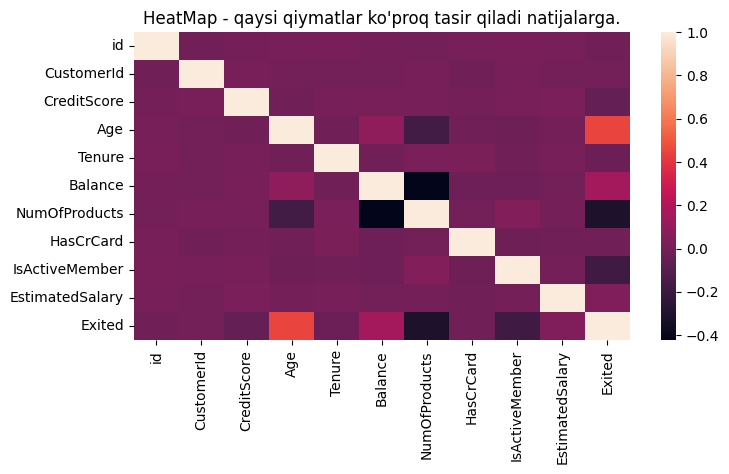

In [11]:
plt.figure(figsize=(8, 4))
sns.heatmap(df.corr(numeric_only=True))
plt.title("HeatMap - qaysi qiymatlar ko'proq tasir qiladi natijalarga.")
plt.show()

# Xulosa

Bizning dataset umumiy jihatdan sifatli, ammo ayrim kamchiliklari mavjud.

* **ID** va **CustomerId** ustunlari mavjud. Bu ustunlar mijozni faqat identifikatsiya qilish uchun xizmat qiladi va modelning o‘rganish jarayoniga foydali ma'lumot bermaydi. Shu sababli ularni datasetdan olib tashlaymiz.
* **Surname** (familiya) ustuni ham mijozning kreditni tark etishi yoki etmasligini aniqlashda muhim omil hisoblanmaydi. Bundan tashqari, mashinali o‘qitish modellari matnli qiymatlarni to‘g‘ridan-to‘g‘ri qabul qilmaydi. Shu sababli ushbu ustunni ham olib tashlash mumkin.
* Datasetda **null (bo‘sh)** qiymatlar va **takrorlangan (duplicate)** qatorlar mavjud emas. Bu esa ma'lumotlar sifati yaxshi ekanligini ko‘rsatadi.
* Keyingi bosqichda **Gender** va **Geography** ustunlarining maqsadli o‘zgaruvchi bilan bog‘liqligini (korrelyatsiyasini) tahlil qilamiz. Buning uchun avvalo ushbu kategorik ustunlarni raqamli ko‘rinishga (encoding) o'tkazishimiz kerak bo‘ladi.


# Data processing

In [12]:
df.Geography.unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [13]:
df_1 = df.drop(columns=['Surname','CustomerId','id'])
df_0 = df_1.copy()
df_1 = df_1.replace({"Male":1, "Female":0})
df_1 = df_1.replace({"France":1, "Germany":0,"Spain":2})
df_1

/tmp/ipykernel_1899/1052382819.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_1 = df_1.replace({"Male":1, "Female":0})
/tmp/ipykernel_1899/1052382819.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_1 = df_1.replace({"France":1, "Germany":0,"Spain":2})


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,567.0,1,1,33.0,9.0,0.00,2.0,1.0,0.0,156792.89,0.0
1,628.0,1,0,38.0,3.0,0.00,1.0,1.0,1.0,51987.99,1.0
2,635.0,1,0,29.0,3.0,0.00,2.0,1.0,1.0,113079.19,0.0
3,681.0,1,1,28.0,6.0,0.00,2.0,1.0,0.0,14081.64,0.0
4,587.0,1,0,27.0,5.0,0.00,2.0,1.0,0.0,158958.90,0.0
...,...,...,...,...,...,...,...,...,...,...,...
14995,581.0,1,1,35.0,1.0,0.00,2.0,1.0,0.0,161653.50,0.0
14996,806.0,0,1,42.0,1.0,129120.64,2.0,1.0,1.0,161642.08,0.0
14997,620.0,1,0,29.0,7.0,0.00,2.0,1.0,1.0,161579.85,0.0
14998,622.0,0,1,51.0,6.0,106070.89,3.0,1.0,0.0,136869.31,1.0


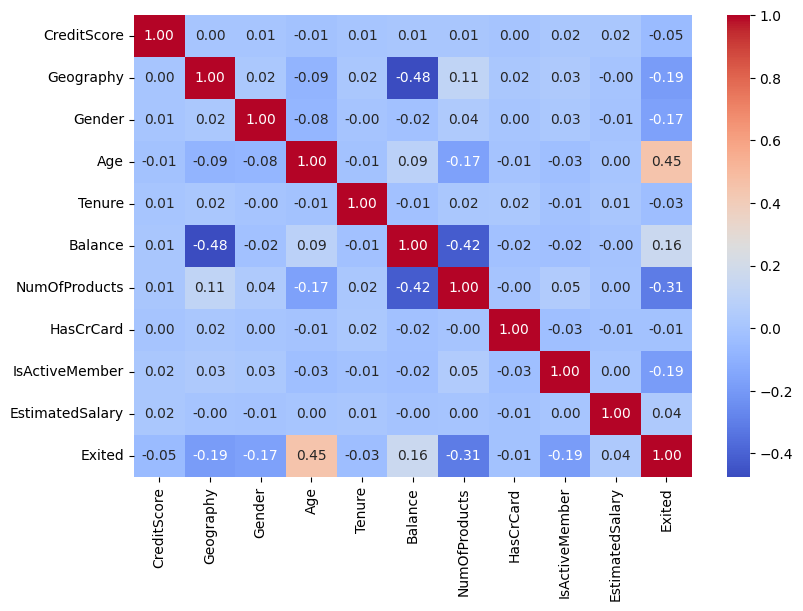

In [14]:
plt.figure(figsize=(9,6))
sns.heatmap(df_1.corr(),annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [15]:
# sns.histplot(df_1)

In [16]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      15000 non-null  float64
 1   Geography        15000 non-null  int64  
 2   Gender           15000 non-null  int64  
 3   Age              15000 non-null  float64
 4   Tenure           15000 non-null  float64
 5   Balance          15000 non-null  float64
 6   NumOfProducts    15000 non-null  float64
 7   HasCrCard        15000 non-null  float64
 8   IsActiveMember   15000 non-null  float64
 9   EstimatedSalary  15000 non-null  float64
 10  Exited           15000 non-null  float64
dtypes: float64(9), int64(2)
memory usage: 1.3 MB


Biz deyarliy ma'lumotlarni tayorlab oldik. Endi ma'lumotlarni modelarga o'qitib ko'ramiz.

In [17]:
#biz modelga target qiymatni alohida berishimiz kerak bo'ladi.
y = df_1['Exited']
X = df_1.drop(columns="Exited")


In [18]:
normalizes = StandardScaler()
X = normalizes.fit_transform(X)
X

array([[-1.25015692, -0.06358559,  0.87708905, ...,  0.53242593,
        -0.99203175,  0.86541443],
       [-0.41081884, -0.06358559, -1.14013508, ...,  0.53242593,
         1.00803226, -1.41067931],
       [-0.31450136, -0.06358559, -1.14013508, ...,  0.53242593,
         1.00803226, -0.08393507],
       ...,
       [-0.52089597, -0.06358559, -1.14013508, ...,  0.53242593,
         1.00803226,  0.96937493],
       [-0.49337668, -1.65322522,  0.87708905, ...,  0.53242593,
        -0.99203175,  0.43272535],
       [-1.5803883 , -0.06358559,  0.87708905, ...,  0.53242593,
         1.00803226,  1.01255962]])

In [19]:
#Biz train uchun alohida hamda test uchun alohida ma'lumot berishimiz kerak boladi
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
y_train

,Exited
9839,1.0
9680,0.0
7093,1.0
11293,0.0
820,0.0
...,...
5191,0.0
13418,1.0
5390,1.0
860,0.0


In [21]:
X_train

array([[-1.74550399, -1.65322522,  0.87708905, ..., -1.87819554,
         1.00803226,  0.52544295],
       [-0.61721345, -1.65322522,  0.87708905, ...,  0.53242593,
         1.00803226, -1.14165653],
       [-0.0255489 , -1.65322522,  0.87708905, ...,  0.53242593,
         1.00803226,  1.38241473],
       ...,
       [ 1.32289589, -1.65322522,  0.87708905, ...,  0.53242593,
        -0.99203175, -0.56608517],
       [ 0.67619277,  1.52605405,  0.87708905, ..., -1.87819554,
         1.00803226, -0.95710327],
       [-0.82360806, -0.06358559,  0.87708905, ...,  0.53242593,
        -0.99203175,  0.55235324]])

# LogisticRegression

In [22]:
model = LogisticRegressionCV()
model.fit(X_train,y_train)

LogisticRegressionCV()

In [23]:
y_pred = model.predict(X_test)

In [24]:
confusion_matrix(y_test,y_pred)

array([[2309,  115],
       [ 269,  307]])

In [47]:
Acur_LR = accuracy_score(y_test,y_pred)

# SVM

In [26]:
clf = svm.SVC()

In [27]:
clf.fit(X_train,y_train)

SVC()

In [28]:
pred_clf = clf.predict(X_test)

In [29]:
confusion_matrix(y_test, pred_clf)

array([[2321,  103],
       [ 207,  369]])

In [49]:
Accur_CLF = accuracy_score(y_test,pred_clf)
Accur_CLF

0.8966666666666666

In [31]:
data = pd.DataFrame(pred_clf)
data

,0
0,1.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
2995,0.0
2996,0.0
2997,0.0
2998,0.0


# DecisionTreeClassifier

In [50]:
d_model = tree.DecisionTreeClassifier(max_depth=10,min_samples_split=5)

In [51]:
d_model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=10, min_samples_split=5)

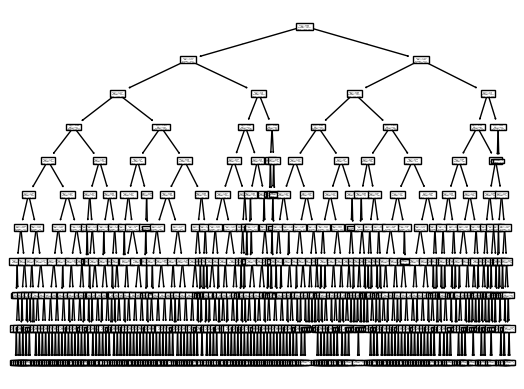

In [52]:
tree.plot_tree(d_model)
plt.show()

In [53]:
pred_d = d_model.predict(X_test)

In [54]:
confusion_matrix(y_test,pred_d)

array([[2245,  179],
       [ 205,  371]])

In [56]:
accur_DEc = accuracy_score(y_test,pred_d)
accur_DEc

0.872

# KNeighborsClassifier

In [38]:
model_knn = KNeighborsClassifier()

In [39]:
model_knn.fit(X_train,y_train)

KNeighborsClassifier()

In [40]:
pred_knn = model_knn.predict(X_test)

In [57]:
accur_kn = accuracy_score(y_test,pred_knn)
accur_kn

0.8523333333333334

# MinMax Scaler

In [42]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X_train)

In [44]:
model_knn.fit(X_scaled,y_train)

KNeighborsClassifier()

In [45]:
pred_knn = model_knn.predict(X_test)

In [46]:
accuracy_score(y_test,pred_knn)

0.8523333333333334

(0.872, 0.8966666666666666, 0.872, 0.8523333333333334)

# Report

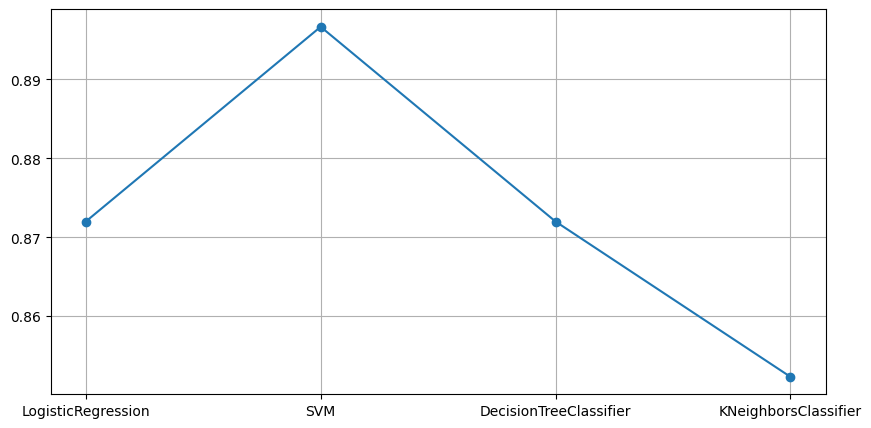

In [70]:
plt.figure(figsize=(10,5))
plt.plot(["LogisticRegression","SVM","DecisionTreeClassifier","KNeighborsClassifier"],[Acur_LR, Accur_CLF, accur_DEc, accur_kn], marker = "o")
plt.grid()
plt.show()

# Xulosa:
- Ma'lumotlar juda ham yaxshi tuzilgan men ma'lumotlarni biroz qayta ishladim hamda bazi joylarini o'zgartirish kiritim. Shuningdek 4 turdagi algorithm lar billan o'qitib ko'rdim, eng yaxshisi bu SVM ekanligini ko'rish mumkin.